In [2]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, MinMaxScaler, PowerTransformer, OrdinalEncoder
from sklearn.model_selection import train_test_split

In [3]:
import dagshub
dagshub.init(repo_owner='Sovith07', repo_name='swiggy_delivery_time', mlflow=True)

Accessing as Sovith07

Initialized MLflow to track repo "Sovith07/swiggy_delivery_time"

Repository Sovith07/swiggy_delivery_time initialized!

In [4]:
import mlflow

In [5]:
# set the tracking server

mlflow.set_tracking_uri("https://dagshub.com/Sovith07/swiggy_delivery_time.mlflow")

In [6]:
# mlflow experiment

mlflow.set_experiment("Exp 3 - XGB HP Tuning")

<Experiment: artifact_location='mlflow-artifacts:/4438e4fdce2449cc86825041c7bb6508', creation_time=1788174687012, effective_trace_archival_retention=None, experiment_id='4', last_update_time=1788174687012, lifecycle_stage='active', name='Exp 3 - XGB HP Tuning', tags={}, trace_location=None, workspace='default'>

In [7]:
from sklearn import set_config

set_config(transform_output="pandas")

# Load the Data

In [8]:
# load the cleaned data

df = pd.read_csv(r'D:\vs code projects\swiggy_delivery_time\data\raw\final_data.csv')

df

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance,distance_type
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149,short
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,BANG,25,3,friday,0,5.0,19.0,evening,20.183530,very_long
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758,short
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401,medium
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56877,JAPRES01DEL01,35.0,4.6,26.905190,75.810753,27.015190,75.920753,2022-03-27,sunny,jam,...,JAP,27,3,sunday,1,10.0,21.0,night,16.384901,very_long
56878,JAPRES11DEL01,33.0,4.9,26.902940,75.793007,26.912940,75.803007,2022-03-11,sandstorms,high,...,JAP,11,3,friday,0,5.0,11.0,morning,1.489842,short
56879,SURRES11DEL03,NaN,NaN,21.157735,72.768778,21.217735,72.828778,2022-03-11,NaN,NaN,...,SUR,11,3,friday,0,NaN,NaN,after_midnight,9.121874,medium
56880,VADRES03DEL02,27.0,4.7,22.320000,73.170000,22.450000,73.300000,2022-03-06,sandstorms,medium,...,VAD,6,3,sunday,1,5.0,18.0,evening,19.687777,very_long


In [9]:
df.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance', 'distance_type'],
      dtype='str')

In [10]:
# drop columns not required for model input

columns_to_drop =  ['rider_id',
                    'restaurant_latitude',
                    'restaurant_longitude',
                    'delivery_latitude',
                    'delivery_longitude',
                    'order_date',
                    "order_time_hour",
                    "order_day",
                    "city_name",
                    "order_day_of_week",
                    "order_month"]

df.drop(columns=columns_to_drop, inplace=True)

df

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
0,37.0,4.9,sunny,high,2,snack,motorcycle,0.0,no,urban,24,1,15.0,morning,3.025149,short
1,34.0,4.5,stormy,jam,2,snack,scooter,1.0,no,metropolitian,33,0,5.0,evening,20.183530,very_long
2,23.0,4.4,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,26,1,15.0,morning,1.552758,short
3,38.0,4.7,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,21,0,10.0,evening,7.790401,medium
4,32.0,4.6,cloudy,high,1,snack,scooter,1.0,no,metropolitian,30,1,15.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56877,35.0,4.6,sunny,jam,1,snack,scooter,1.0,no,metropolitian,16,1,10.0,night,16.384901,very_long
56878,33.0,4.9,sandstorms,high,1,drinks,scooter,1.0,no,metropolitian,12,0,5.0,morning,1.489842,short
56879,NaN,NaN,NaN,NaN,3,drinks,scooter,1.0,no,metropolitian,18,0,NaN,after_midnight,9.121874,medium
56880,27.0,4.7,sandstorms,medium,0,meal,motorcycle,0.0,no,metropolitian,36,1,5.0,evening,19.687777,very_long


In [11]:
# check for missing values

df.isna().sum()

age                    2345
ratings                2415
weather                 664
traffic                 645
vehicle_condition         0
type_of_order             0
type_of_vehicle           0
multiple_deliveries    1231
festival                293
city_type              1522
time_taken                0
is_weekend                0
pickup_time_minutes    2065
order_time_of_day         0
distance               4499
distance_type          4499
dtype: int64

In [12]:
# check for duplicates

df.duplicated().sum()

np.int64(1)

In [13]:
df=df.drop_duplicates()

<Axes: >

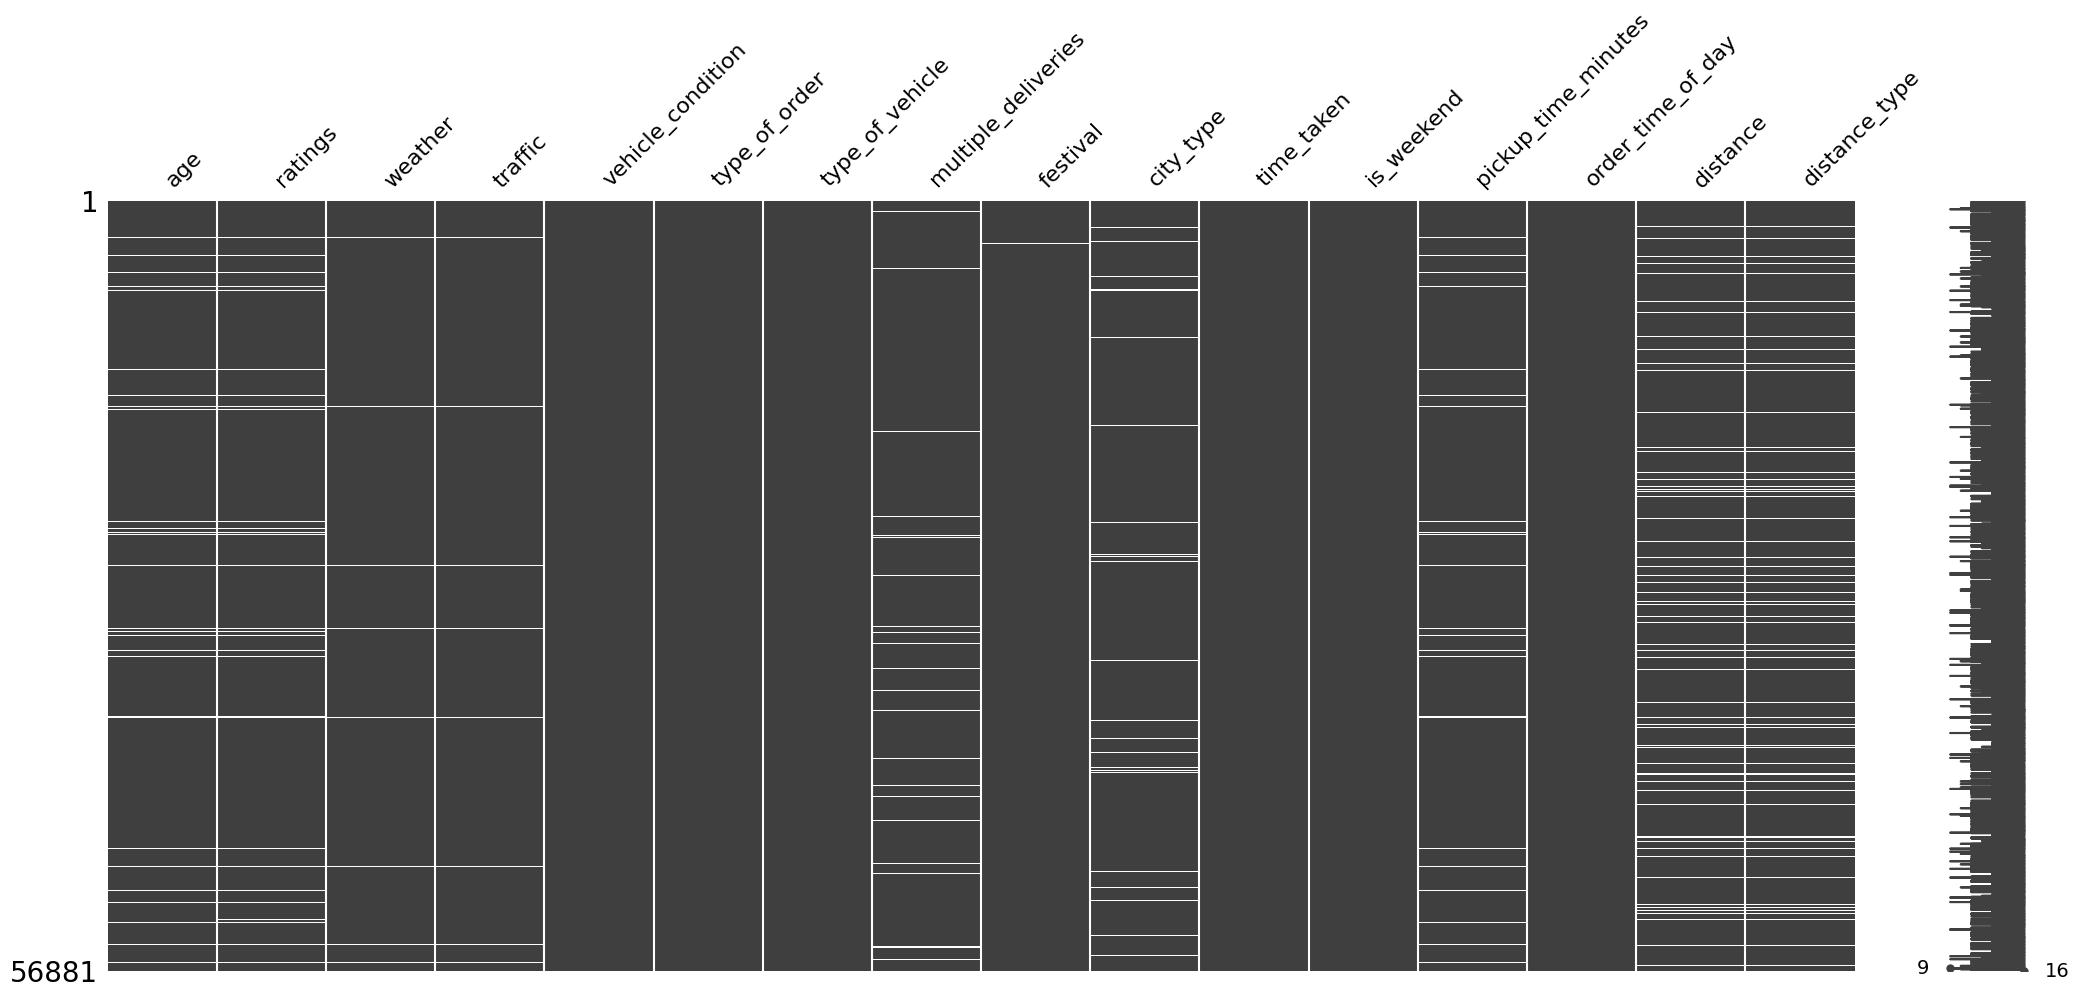

In [14]:
import missingno as msno

msno.matrix(df)

In [15]:
# columns that have missing values

missing_cols = (
                    df
                    .isna()
                    .any(axis=0)
                    .loc[lambda x: x]
                    .index
                )

missing_cols

Index(['age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'pickup_time_minutes', 'distance',
       'distance_type'],
      dtype='str')

# Drop Missing values

In [16]:
temp_df = df.copy().dropna()

In [17]:
# split into X and y

X = temp_df.drop(columns='time_taken')
y = temp_df['time_taken']

X

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
0,37.0,4.9,sunny,high,2,snack,motorcycle,0.0,no,urban,1,15.0,morning,3.025149,short
1,34.0,4.5,stormy,jam,2,snack,scooter,1.0,no,metropolitian,0,5.0,evening,20.183530,very_long
2,23.0,4.4,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,1,15.0,morning,1.552758,short
3,38.0,4.7,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,0,10.0,evening,7.790401,medium
4,32.0,4.6,cloudy,high,1,snack,scooter,1.0,no,metropolitian,1,15.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56873,31.0,5.0,fog,low,0,meal,motorcycle,1.0,no,metropolitian,1,15.0,night,13.612341,long
56877,35.0,4.6,sunny,jam,1,snack,scooter,1.0,no,metropolitian,1,10.0,night,16.384901,very_long
56878,33.0,4.9,sandstorms,high,1,drinks,scooter,1.0,no,metropolitian,0,5.0,morning,1.489842,short
56880,27.0,4.7,sandstorms,medium,0,meal,motorcycle,0.0,no,metropolitian,1,5.0,evening,19.687777,very_long


In [18]:
# train test split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
print("The size of train data is",X_train.shape)
print("The shape of test data is",X_test.shape)

The size of train data is (38067, 15)
The shape of test data is (9517, 15)


In [20]:
# missing values in train data

X_train.isna().sum()

age                    0
ratings                0
weather                0
traffic                0
vehicle_condition      0
type_of_order          0
type_of_vehicle        0
multiple_deliveries    0
festival               0
city_type              0
is_weekend             0
pickup_time_minutes    0
order_time_of_day      0
distance               0
distance_type          0
dtype: int64

In [21]:
# transform target column

pt = PowerTransformer()

y_train_pt = pt.fit_transform(y_train.values.reshape(-1,1))
y_test_pt = pt.transform(y_test.values.reshape(-1,1))

In [22]:
missing_cols

Index(['age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'pickup_time_minutes', 'distance',
       'distance_type'],
      dtype='str')

In [23]:
# percentage of rows in data having missing values

(
    X_train
    .isna()
    .any(axis=1)
    .mean()
    .round(2) * 100
)


np.float64(0.0)

# Pre-Processing Pipeline

In [24]:
num_cols = ["age","ratings","pickup_time_minutes","distance"]

nominal_cat_cols = ['weather',
                    'type_of_order',
                    'type_of_vehicle',
                    "festival",
                    "city_type",
                    "is_weekend",
                    "order_time_of_day"]

ordinal_cat_cols = ["traffic","distance_type"]

In [25]:
nominal_cat_cols

['weather',
 'type_of_order',
 'type_of_vehicle',
 'festival',
 'city_type',
 'is_weekend',
 'order_time_of_day']

In [26]:
X_train.isna().sum()

age                    0
ratings                0
weather                0
traffic                0
vehicle_condition      0
type_of_order          0
type_of_vehicle        0
multiple_deliveries    0
festival               0
city_type              0
is_weekend             0
pickup_time_minutes    0
order_time_of_day      0
distance               0
distance_type          0
dtype: int64

In [27]:
# # features to fill values with mode

# features_to_fill_mode = ['multiple_deliveries','festival','city_type']
# features_to_fill_missing = [col for col in nominal_cat_cols if col not in features_to_fill_mode]

# features_to_fill_missing

In [28]:
# # simple imputer to fill categorical vars with mode

# simple_imputer = ColumnTransformer(transformers=[
#     ("mode_imputer",SimpleImputer(strategy="most_frequent",add_indicator=True),features_to_fill_mode),
#     ("missing_imputer",SimpleImputer(strategy="constant",fill_value="missing",add_indicator=True),features_to_fill_missing)
# ],remainder="passthrough",n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)

# simple_imputer

In [29]:
# simple_imputer.fit_transform(X_train)

In [30]:
# simple_imputer.fit_transform(X_train).isna().sum()

In [31]:
# knn imputer

# knn_imputer = KNNImputer(n_neighbors=5)

In [32]:
# do basic preprocessing

num_cols = ["age","ratings","pickup_time_minutes","distance"]

nominal_cat_cols = ['weather','type_of_order',
                    'type_of_vehicle',"festival",
                    "city_type",
                    "is_weekend",
                    "order_time_of_day"]

ordinal_cat_cols = ["traffic","distance_type"]

In [33]:
# generate order for ordinal encoding

traffic_order = ["low","medium","high","jam"]

distance_type_order = ["short","medium","long","very_long"]

In [34]:
# unique categories the ordinal columns

for col in ordinal_cat_cols:
    print(col,X_train[col].unique())

traffic <ArrowStringArray>
['low', 'medium', 'jam', 'high']
Length: 4, dtype: str
distance_type <ArrowStringArray>
['medium', 'very_long', 'short', 'long']
Length: 4, dtype: str


In [35]:
# build a preprocessor

preprocessor = ColumnTransformer(transformers=[
    ("scale", MinMaxScaler(), num_cols),
    ("nominal_encode", OneHotEncoder(drop="first",handle_unknown="ignore",
                                     sparse_output=False), nominal_cat_cols),
    ("ordinal_encode", OrdinalEncoder(categories=[traffic_order,distance_type_order],
                                      encoded_missing_value=np.nan,
                                      handle_unknown="use_encoded_value",
                                      unknown_value=-1), ordinal_cat_cols)
],remainder="passthrough",n_jobs=-1,verbose_feature_names_out=False)


preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scale', ...), ('nominal_encode', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",-1
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for featur

In [36]:
# build the pipeline

processing_pipeline = Pipeline(steps=[
                                # ("simple_imputer",simple_imputer),
                                ("preprocess",preprocessor)
                                # ("knn_imputer",knn_imputer)
                            ])

processing_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scale', ...), ('nominal_encode', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to ru

In [37]:
# do data preprocessing

X_train_trans = processing_pipeline.fit_transform(X_train)

X_test_trans = processing_pipeline.transform(X_test)

In [38]:
X_train_trans

,age,ratings,pickup_time_minutes,distance,weather_fog,weather_sandstorms,weather_stormy,weather_sunny,weather_windy,type_of_order_drinks,...,city_type_urban,is_weekend_1,order_time_of_day_afternoon,order_time_of_day_evening,order_time_of_day_morning,order_time_of_day_night,traffic,distance_type,vehicle_condition,multiple_deliveries
43943,0.315789,0.84,0.5,0.397618,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,2,1.0
15062,0.631579,0.68,0.5,0.960872,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,1.0,0.0,0.0,1.0,3.0,2,0.0
26124,0.105263,0.92,0.0,0.318855,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1,1.0
15942,0.526316,1.00,0.5,0.079729,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,2,0.0
7348,0.789474,0.84,0.5,0.800358,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,3.0,3.0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13483,0.736842,0.92,0.5,0.154044,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2,1.0
53483,0.368421,1.00,0.0,0.163993,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,3.0,0.0,0,1.0
45614,0.052632,0.96,0.0,0.930756,0.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,0,0.0
1038,0.368421,0.92,0.5,0.992901,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,2,1.0


In [39]:
from xgboost import XGBRegressor
import optuna

In [40]:
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.compose import TransformedTargetRegressor

In [41]:
def objective(trial):
    with mlflow.start_run(nested=True):
        params = {
    "n_estimators": trial.suggest_int("n_estimators", 50, 1000),
    "max_depth": trial.suggest_int("max_depth", 3, 10),          # 1-40 is way too wide for XGB; trees this deep overfit fast
    "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),  # 0.1-0.8 upper bound is too aggressive
    "subsample": trial.suggest_float("subsample", 0.5, 1.0),
    "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),  # missing — important XGB regularizer
    "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),        # 5-20 floor may be too restrictive; let it search from 1
    "gamma": trial.suggest_float("gamma", 0, 10),                # XGBoost calls this "gamma", not "min_split_gain"
    "reg_alpha": trial.suggest_float("reg_alpha", 0, 10, log=False),  # L1 — worth tuning alongside lambda
    "reg_lambda": trial.suggest_float("reg_lambda", 0, 100),
    "random_state": 42,
    "n_jobs": -1,
}

        # log model parameters
        mlflow.log_params(params)

        # build the model
        rf = XGBRegressor(**params)
        model = TransformedTargetRegressor(regressor=rf,transformer=pt)

        # train the model
        model.fit(X_train_trans,y_train)

        # get the predictions
        y_pred_train = model.predict(X_train_trans)
        y_pred_test = model.predict(X_test_trans)


        # perform cross validation
        cv_score = cross_val_score(model,
                                X_train_trans,
                                y_train,
                                cv=5,
                                scoring="neg_mean_absolute_error",
                                n_jobs=-1)

        # mean score
        mean_score = -(cv_score.mean())

        # log avg cross val error
        mlflow.log_metric("cross_val_error",mean_score)

        return mean_score

In [42]:
from sklearn.compose import TransformedTargetRegressor

In [43]:
# create optuna study
study = optuna.create_study(direction="minimize")

with mlflow.start_run(run_name="best_model"):
    # optimize the objective function
    study.optimize(objective,n_trials=250,n_jobs=1,show_progress_bar=True)

    # log the best parameters
    mlflow.log_params(study.best_params)

    # log the best score
    mlflow.log_metric("best_score",study.best_value)

    # train the model on best parameters
    best_xgb = XGBRegressor(**study.best_params)

    best_xgb.fit(X_train_trans,y_train_pt.values.ravel())

    # get the predictions
    y_pred_train = best_xgb.predict(X_train_trans)
    y_pred_test = best_xgb.predict(X_test_trans)

    # get the actual predictions values
    y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
    y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))


    # perform cross validation
    model = TransformedTargetRegressor(regressor=best_xgb,
                                        transformer=pt)


    scores = cross_val_score(model,
                         X_train_trans,
                         y_train,
                         scoring="neg_mean_absolute_error",
                         cv=5,n_jobs=-1)

    # log metrics
    mlflow.log_metric("training_error",mean_absolute_error(y_train,y_pred_train_org))
    mlflow.log_metric("test_error",mean_absolute_error(y_test,y_pred_test_org))
    mlflow.log_metric("training_r2",r2_score(y_train,y_pred_train_org))
    mlflow.log_metric("test_r2",r2_score(y_test,y_pred_test_org))
    mlflow.log_metric("cross_val",- scores.mean())

    # log the best model
    mlflow.sklearn.log_model(best_xgb,artifact_path="model")

[I 2026-08-31 19:59:50,782] A new study created in memory with name: no-name-0d03ae3f-5586-4d86-94ec-7e6fdad7a3b5


  0%|          | 0/250 [00:00<?, ?it/s]

🏃 View run flawless-loon-642 at: https://dagshub.com/Sovith07/swiggy_delivery_time.mlflow/#/experiments/4/runs/ddd8b6ef64734c60b53b20560060c914
🧪 View experiment at: https://dagshub.com/Sovith07/swiggy_delivery_time.mlflow/#/experiments/4
[I 2026-08-31 20:00:04,457] Trial 0 finished with value: 4.883390140533447 and parameters: {'n_estimators': 383, 'max_depth': 8, 'learning_rate': 0.12758722622171204, 'subsample': 0.6757420684956807, 'colsample_bytree': 0.5894129421856453, 'min_child_weight': 7, 'gamma': 8.746146649289955, 'reg_alpha': 1.8663562761745622, 'reg_lambda': 69.1293193082282}. Best is trial 0 with value: 4.883390140533447.
🏃 View run worried-penguin-444 at: https://dagshub.com/Sovith07/swiggy_delivery_time.mlflow/#/experiments/4/runs/af41123a44814a43ace277dc9332f876
🧪 View experiment at: https://dagshub.com/Sovith07/swiggy_delivery_time.mlflow/#/experiments/4
[I 2026-08-31 20:00:17,057] Trial 1 finished with value: 4.662584400177002 and parameters: {'n_estimators': 693, 'ma

2026/08/31 20:39:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/31 20:39:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run best_model at: https://dagshub.com/Sovith07/swiggy_delivery_time.mlflow/#/experiments/4/runs/61f9cef37c054e3d90ff1e2b429a37ac
🧪 View experiment at: https://dagshub.com/Sovith07/swiggy_delivery_time.mlflow/#/experiments/4


In [44]:
study.best_params

{'n_estimators': 716,
 'max_depth': 10,
 'learning_rate': 0.022190849275494005,
 'subsample': 0.9618348256588674,
 'colsample_bytree': 0.9650165052381436,
 'min_child_weight': 10,
 'gamma': 0.18799990841416653,
 'reg_alpha': 6.869029486168006,
 'reg_lambda': 72.93886465167222}

In [45]:
study.best_value

4.580449199676513

In [46]:
# optimization history plot

optuna.visualization.plot_optimization_history(study)

In [47]:
# plot hyperparameter importance plot

optuna.visualization.plot_param_importances(study)

In [48]:
# slice plot

optuna.visualization.plot_slice(study)